# Actividad 2. Transformación e ingeniería de características

## Objetivo

Transformar el conjunto de datos depurado obtenido en la Actividad 1 mediante la construcción de variables derivadas que describan el rendimiento académico, la evolución del desempeño, la puntualidad en las evaluaciones y el nivel de interacción de los estudiantes dentro del entorno virtual de aprendizaje. El propósito es generar un conjunto de datos enriquecido que facilite el entrenamiento de modelos de Machine Learning orientados a la identificación temprana del riesgo académico.

---

## Relación con la metodología

Esta actividad corresponde principalmente a la fase **Data Preparation** de las metodologías **CRISP-DM** y **CRISP-ML(Q)**.

Durante esta etapa se definió la variable objetivo del problema de clasificación y se desarrolló un proceso de ingeniería de características a partir del conjunto de datos consolidado y de los registros de interacción del entorno virtual. Se construyeron indicadores académicos, temporales y de comportamiento mediante técnicas de agregación y análisis estadístico, los cuales fueron integrados en un único conjunto de datos a nivel de estudiante, módulo y presentación.

Finalmente, se realizó un análisis descriptivo y exploratorio de las nuevas variables, se evaluó su correlación y se exportó el dataset enriquecido, el cual será utilizado como entrada para la fase de preprocesamiento final y entrenamiento de los modelos predictivos en la Actividad 3.

# 2. Importación de librerías

En esta sección se importan las bibliotecas necesarias para realizar las tareas de transformación e ingeniería de características del conjunto de datos. Estas herramientas permitirán manipular la información, efectuar operaciones de agregación, generar nuevas variables y visualizar los resultados obtenidos durante el proceso de preparación de los datos.

In [1]:
# ==========================================
# Manipulación de datos
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# Visualización
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Análisis estadístico
# ==========================================

from scipy.stats import linregress

# ==========================================
# Configuración general
# ==========================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


Las bibliotecas importadas proporcionan las funcionalidades necesarias para desarrollar las actividades de transformación e ingeniería de características. En particular, **Pandas** y **NumPy** permiten realizar operaciones de manipulación y agregación de datos, mientras que **SciPy** será utilizada para calcular indicadores relacionados con la evolución temporal del rendimiento académico de los estudiantes.

# 3. Carga del conjunto de datos depurado

En esta sección se carga el conjunto de datos generado durante la Actividad 1, el cual contiene la información integrada y depurada proveniente de las tablas principales del dataset OULAD.

Adicionalmente, se carga la tabla **studentVle**, ya que será utilizada posteriormente para construir variables relacionadas con el comportamiento de los estudiantes dentro del entorno virtual de aprendizaje. Esta información no fue integrada directamente durante la actividad anterior debido a su naturaleza transaccional y al elevado número de registros que contiene.

In [2]:
# ==========================================
# Rutas de trabajo
# ==========================================

INTERIM_PATH = "../data/interim/"
RAW_PATH = "../data/raw/"

# ==========================================
# Dataset depurado (Actividad 1)
# ==========================================

student_data = pd.read_csv(
    INTERIM_PATH + "student_data_clean.csv"
)

# ==========================================
# Tabla de interacciones
# ==========================================

studentVle = pd.read_csv(
    RAW_PATH + "studentVle.csv"
)

print("Archivos cargados correctamente.")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_18308\3876781429.py:12: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  student_data = pd.read_csv(


Archivos cargados correctamente.


Se dispone ahora de dos fuentes de información que serán utilizadas durante esta actividad. La primera corresponde al conjunto de datos depurado obtenido en la Actividad 1, mientras que la segunda contiene los registros detallados de interacción de los estudiantes dentro del entorno virtual de aprendizaje. Ambas fuentes serán complementadas mediante procesos de ingeniería de características para generar variables con mayor capacidad descriptiva y predictiva.

# 4. Verificación y adecuación de los tipos de datos

Previo a la ingeniería de características, se verifican y transforman las variables numéricas que el formato CSV importó erróneamente como texto. Esto asegura la validez de los cálculos estadísticos y la correcta construcción de los nuevos indicadores.

In [3]:
# ==========================================
# Verificación inicial de tipos de datos
# ==========================================

student_data.dtypes

code_module              object
code_presentation        object
id_student                int64
gender                   object
region                   object
highest_education        object
imd_band                 object
age_band                 object
num_of_prev_attempts      int64
studied_credits           int64
disability               object
final_result             object
id_assessment           float64
date_submitted          float64
is_banked               float64
score                    object
assessment_type          object
date                     object
weight                  float64
dtype: object

In [4]:
# ==========================================
# Conversión de variables numéricas
# ==========================================

numeric_columns = [

    "id_assessment",
    "date_submitted",
    "score",
    "date",
    "weight",
    "studied_credits",
    "num_of_prev_attempts"

]

for col in numeric_columns:

    student_data[col] = pd.to_numeric(
        student_data[col],
        errors="coerce"
    )

print(student_data[numeric_columns].dtypes)

id_assessment           float64
date_submitted          float64
score                   float64
date                    float64
weight                  float64
studied_credits           int64
num_of_prev_attempts      int64
dtype: object


In [5]:
datasets = {
    "student_data": student_data,
    "studentVle": studentVle
}

summary = []

for name, df in datasets.items():

    summary.append([
        name,
        df.shape[0],
        df.shape[1]
    ])

summary = pd.DataFrame(
    summary,
    columns=[
        "Dataset",
        "Registros",
        "Variables"
    ]
)

summary

,Dataset,Registros,Variables
0,student_data,180662,19
1,studentVle,10655280,6


In [6]:
student_data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1752.0,18.0,0.0,78.0,TMA,19.0,10.0
1,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1753.0,53.0,0.0,85.0,TMA,54.0,20.0
2,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1754.0,115.0,0.0,80.0,TMA,117.0,20.0
3,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1755.0,164.0,0.0,85.0,TMA,166.0,20.0
4,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1756.0,212.0,0.0,82.0,TMA,215.0,30.0


In [7]:
studentVle.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


La verificación confirma que el conjunto de datos depurado y la tabla de interacciones fueron cargados correctamente. Se observa que **student_data** contiene la información consolidada obtenida durante la Actividad 1, mientras que **studentVle** conserva el detalle de las interacciones realizadas por los estudiantes dentro del entorno virtual, información que será resumida mediante técnicas de agregación en las siguientes secciones.

# 5. Creación de copias de trabajo

Con el propósito de preservar la integridad de los datos originales cargados desde los archivos fuente, se crean copias independientes que serán utilizadas durante el proceso de transformación e ingeniería de características.

Este procedimiento permite mantener la trazabilidad del flujo de trabajo y facilita la reproducibilidad de los experimentos desarrollados en el proyecto.

In [8]:
student_data_df = student_data.copy()

studentVle_df = studentVle.copy()

print("Copias de trabajo creadas correctamente.")

Copias de trabajo creadas correctamente.


Las copias de trabajo constituyen la base sobre la cual se realizarán todas las transformaciones de esta actividad. De esta manera, los archivos originales permanecen sin modificaciones, permitiendo repetir el proceso completo de preparación de datos cuando sea necesario.

# 6. Definición de la variable objetivo

Antes de construir las nuevas variables predictoras, es necesario definir la variable objetivo que será utilizada posteriormente durante el entrenamiento de los modelos de Machine Learning.

En el dataset OULAD, el rendimiento final del estudiante se encuentra representado por la variable **final_result**, la cual clasifica el resultado académico en cuatro categorías: **Pass**, **Distinction**, **Fail** y **Withdrawn**.

Para este proyecto, el problema se plantea como una tarea de **clasificación binaria del riesgo académico**. En consecuencia, los estudiantes que aprobaron el módulo (**Pass** y **Distinction**) se consideran casos sin riesgo académico, mientras que aquellos que reprobaron o abandonaron el curso (**Fail** y **Withdrawn**) se clasifican como estudiantes en riesgo académico.

Esta transformación simplifica el problema de clasificación y permite orientar el entrenamiento de los modelos hacia la identificación temprana de estudiantes que requieren intervención académica.

In [9]:
# ==========================================
# Distribución original de final_result
# ==========================================

student_data_df["final_result"].value_counts()

final_result
Pass           106024
Fail            29750
Distinction     26330
Withdrawn       18558
Name: count, dtype: int64

La distribución de la variable **final_result** permite conocer la cantidad de estudiantes presentes en cada una de las categorías académicas originales del dataset OULAD. Esta información sirve como punto de partida para justificar la construcción de una variable objetivo binaria orientada a la predicción del riesgo académico.

In [10]:
# ==========================================
# Construcción de la variable objetivo
# ==========================================

student_data_df["academic_risk"] = (
    student_data_df["final_result"]
    .map({
        "Pass": 0,
        "Distinction": 0,
        "Fail": 1,
        "Withdrawn": 1
    })
)

print("Variable objetivo creada correctamente.")

Variable objetivo creada correctamente.


In [11]:
student_data_df["academic_risk"].value_counts()

academic_risk
0    132354
1     48308
Name: count, dtype: int64

In [12]:
risk_distribution = (
    student_data_df["academic_risk"]
    .value_counts()
    .rename(index={
        0: "Sin riesgo",
        1: "En riesgo"
    })
)

risk_distribution

academic_risk
Sin riesgo    132354
En riesgo      48308
Name: count, dtype: int64

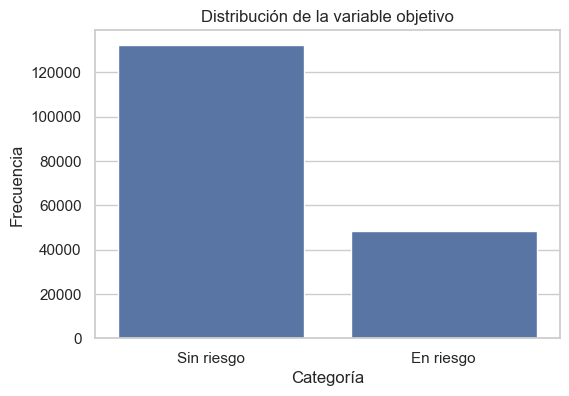

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=student_data_df,
    x="academic_risk"
)

plt.xticks(
    [0,1],
    ["Sin riesgo","En riesgo"]
)

plt.xlabel("Categoría")

plt.ylabel("Frecuencia")

plt.title("Distribución de la variable objetivo")

plt.show()

La variable **academic_risk** representa la variable objetivo del proyecto. En ella, el valor **0** identifica a los estudiantes que completaron satisfactoriamente el módulo, mientras que el valor **1** representa a aquellos estudiantes que reprobaron o abandonaron el curso.

Esta representación binaria resulta adecuada para entrenar modelos supervisados de clasificación y se encuentra alineada con el objetivo de identificar de manera temprana a los estudiantes con mayor probabilidad de presentar riesgo académico.

Asimismo, la distribución de la variable objetivo evidencia un desbalance moderado entre las clases "Sin riesgo" y "En riesgo". No obstante, durante esta actividad no se realizará ninguna técnica de balanceo, ya que las buenas prácticas de Machine Learning establecen que procedimientos como SMOTE deben aplicarse únicamente sobre el conjunto de entrenamiento, una vez realizada la partición de los datos. Este procedimiento será desarrollado en la Actividad 3 con el fin de evitar problemas de fuga de información (Data Leakage).

# 7. Definición de las claves de agrupación

Las variables derivadas que se construirán durante esta actividad representan indicadores académicos y de interacción calculados para cada estudiante dentro de un módulo y una presentación específica.

Por esta razón, se define una única llave de agrupación compuesta por las variables **id_student**, **code_module** y **code_presentation**. Esta combinación identifica de manera única la participación de un estudiante en un curso determinado y será utilizada de forma consistente en todos los procesos de agregación desarrollados posteriormente.

In [14]:
group_cols = [

    "id_student",

    "code_module",

    "code_presentation"

]

group_cols

['id_student', 'code_module', 'code_presentation']

La definición de una llave de agrupación común garantiza la consistencia de todas las variables derivadas generadas durante la ingeniería de características. De esta manera, cada indicador calculado describirá el comportamiento de un estudiante dentro de una presentación específica del módulo, manteniendo la coherencia con la estructura original del dataset OULAD.

La utilización de una única llave de agrupación simplifica el proceso de integración de las variables derivadas y favorece la trazabilidad del flujo de preparación de datos, reduciendo la posibilidad de inconsistencias durante la construcción del conjunto de datos enriquecido.

# 8. Construcción de variables académicas

En esta sección se generan variables derivadas que resumen el desempeño académico de cada estudiante a partir de las calificaciones obtenidas en las diferentes evaluaciones registradas durante el curso.

En lugar de utilizar las calificaciones individuales, se construyen indicadores agregados que describen el comportamiento general del estudiante, permitiendo representar de manera más compacta su rendimiento académico. Entre estos indicadores se incluyen la calificación promedio, máxima y mínima, la variabilidad de las calificaciones y el número total de evaluaciones realizadas.

Estas variables han sido ampliamente utilizadas en investigaciones sobre Learning Analytics debido a que proporcionan información relevante sobre el desempeño global del estudiante y su evolución dentro del proceso de aprendizaje.

In [15]:
# ==========================================
# Construcción de variables académicas
# ==========================================

academic_features = (

    student_data_df

    .groupby(group_cols)

    .agg(

        score_mean=("score", "mean"),

        score_max=("score", "max"),

        score_min=("score", "min"),

        score_std=("score", "std"),

        num_assessments=("score", "count")

    )

    .reset_index()

)

print("Variables académicas construidas correctamente.")

Variables académicas construidas correctamente.


In [16]:
academic_features.head()

,id_student,code_module,code_presentation,score_mean,score_max,score_min,score_std,num_assessments
0,3733,DDD,2013J,NaN,NaN,NaN,NaN,0
1,6516,AAA,2014J,61.800000,77.0,48.0,10.329569,5
2,8462,DDD,2013J,87.666667,93.0,83.0,5.033223,3
3,8462,DDD,2014J,86.500000,93.0,83.0,4.725816,4
4,11391,AAA,2013J,82.000000,85.0,78.0,3.082207,5


In [17]:
academic_features.describe()

,id_student,score_mean,score_max,score_min,score_std,num_assessments
count,3.259300e+04,25820.000000,25820.000000,25820.000000,23301.000000,32593.000000
mean,7.066877e+05,72.768254,86.544191,55.664679,13.243276,5.330562
std,5.491673e+05,16.374997,17.104197,22.193388,7.600832,4.326081
min,3.733000e+03,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.085730e+05,64.666667,80.000000,42.000000,7.767453,1.000000
50%,5.903100e+05,76.000000,92.000000,60.000000,12.020815,5.000000
75%,6.444530e+05,84.545455,100.000000,72.000000,17.133463,9.000000
max,2.716795e+06,100.000000,100.000000,100.000000,70.003571,14.000000


Las variables construidas representan una síntesis del rendimiento académico alcanzado por cada estudiante dentro de un módulo específico.

En particular, **score_mean** resume el desempeño promedio obtenido durante las evaluaciones, **score_max** y **score_min** permiten identificar los mejores y peores resultados alcanzados, mientras que **score_std** mide la variabilidad de las calificaciones obtenidas. Finalmente, **num_assessments** indica la cantidad de evaluaciones registradas para cada estudiante, proporcionando una medida del nivel de participación en las actividades evaluativas del curso.

# 9. Construcción del indicador de rendimiento ponderado

Las evaluaciones presentes en OULAD poseen diferentes niveles de importancia dentro de cada módulo académico, representados mediante la variable **weight**.

Con el propósito de incorporar esta información al proceso de aprendizaje, se calcula un indicador de rendimiento ponderado denominado **weighted_grade**, el cual considera simultáneamente la calificación obtenida por el estudiante y el peso asignado a cada evaluación.

Este indicador permite obtener una estimación más representativa del desempeño académico global que un promedio simple de las calificaciones.

In [18]:
# ==========================================
# Función para calcular promedio ponderado
# ==========================================

def weighted_mean(group):

    total_weight = group["weight"].sum()

    if total_weight == 0:

        return np.nan

    return (
        (group["score"] * group["weight"]).sum()
        / total_weight
    )

In [19]:
weighted_grade = (

    student_data_df

    .groupby(group_cols)

    .apply(weighted_mean)

    .reset_index(name="weighted_grade")

)

print("Variable weighted_grade creada correctamente.")

Variable weighted_grade creada correctamente.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18308\559064664.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(weighted_mean)


In [20]:
weighted_grade.head()

,id_student,code_module,code_presentation,weighted_grade
0,3733,DDD,2013J,NaN
1,6516,AAA,2014J,63.50
2,8462,DDD,2013J,87.25
3,8462,DDD,2014J,86.00
4,11391,AAA,2013J,82.40


In [21]:
weighted_grade.describe()

,id_student,weighted_grade
count,3.259300e+04,23506.000000
mean,7.066877e+05,69.526300
std,5.491673e+05,16.961600
min,3.733000e+03,0.000000
25%,5.085730e+05,59.666667
50%,5.903100e+05,72.000000
75%,6.444530e+05,82.000000
max,2.716795e+06,100.000000


El indicador **weighted_grade** resume el rendimiento académico considerando la importancia relativa de cada evaluación dentro del módulo. A diferencia de un promedio simple, esta variable asigna una mayor contribución a las actividades con mayor peso académico, proporcionando una representación más realista del desempeño global del estudiante.

# 10. Construcción del indicador de evolución del rendimiento

Además del rendimiento promedio, resulta importante analizar cómo evolucionan las calificaciones de cada estudiante durante el desarrollo del módulo. Para ello, se construye la variable **score_trend**, calculada mediante una regresión lineal entre la fecha de cada evaluación y la calificación obtenida.

La pendiente de la regresión representa la tendencia del rendimiento académico, donde valores positivos indican una mejora progresiva, valores cercanos a cero reflejan estabilidad y valores negativos evidencian un deterioro en el desempeño del estudiante.

In [22]:
# ==========================================
# Función para calcular la tendencia del rendimiento
# ==========================================

def calculate_score_trend(group):

    # Eliminar registros sin fecha o sin calificación
    data = group.dropna(
        subset=["date", "score"]
    )

    # Se requieren al menos dos observaciones
    if len(data) < 2:
        return np.nan

    # Se requieren al menos dos fechas distintas
    if data["date"].nunique() < 2:
        return np.nan

    try:

        slope, _, _, _, _ = linregress(
            data["date"],
            data["score"]
        )

        return slope

    except Exception:

        return np.nan


# ==========================================
# Construcción del indicador
# ==========================================

score_trend = (

    student_data_df

    .groupby(group_cols)

    .apply(calculate_score_trend)

    .reset_index(name="score_trend")

)

print("Variable score_trend creada correctamente.")

Variable score_trend creada correctamente.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18308\1132363420.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_score_trend)


In [23]:
score_trend.head()

,id_student,code_module,code_presentation,score_trend
0,3733,DDD,2013J,NaN
1,6516,AAA,2014J,0.097741
2,8462,DDD,2013J,-0.086651
3,8462,DDD,2014J,-0.038402
4,11391,AAA,2013J,0.013705


In [24]:
score_trend.describe()

,id_student,score_trend
count,3.259300e+04,23285.000000
mean,7.066877e+05,-0.019796
std,5.491673e+05,0.496082
min,3.733000e+03,-14.500000
25%,5.085730e+05,-0.096831
50%,5.903100e+05,-0.013915
75%,6.444530e+05,0.053261
max,2.716795e+06,17.500000


## Interpretación de resultados

La variable **score_trend** resume la evolución del rendimiento académico de cada estudiante a lo largo del módulo. Este indicador complementa las variables académicas previamente construidas, incorporando información temporal que puede contribuir a mejorar la capacidad predictiva de los modelos de clasificación.

# 11. Construcción de indicadores de puntualidad

La puntualidad en la entrega de las evaluaciones constituye un indicador del nivel de compromiso y organización del estudiante durante el curso. En esta sección se construyen variables que cuantifican el retraso promedio en las entregas, el número de actividades entregadas fuera del plazo establecido y la proporción de entregas tardías respecto al total de evaluaciones realizadas.

In [25]:
# ==========================================
# Retraso de entrega
# ==========================================

student_data_df["submission_delay"] = (

    student_data_df["date_submitted"]

    -

    student_data_df["date"]

)

In [26]:
# ==========================================
# Identificación de entregas tardías
# ==========================================

student_data_df["late_submission"] = (

    student_data_df["submission_delay"] > 0

).astype(int)

In [27]:
# ==========================================
# Construcción de indicadores
# ==========================================

submission_features = (

    student_data_df

    .groupby(group_cols)

    .agg(

        submission_delay=("submission_delay", "mean"),

        late_submission=("late_submission", "sum"),

        total_assessments=("late_submission", "count")

    )

    .reset_index()

)

submission_features["late_submission_ratio"] = (

    submission_features["late_submission"]

    /

    submission_features["total_assessments"]

)

submission_features.drop(

    columns="total_assessments",

    inplace=True

)

print("Indicadores de puntualidad construidos correctamente.")

Indicadores de puntualidad construidos correctamente.


In [28]:
submission_features.head()

,id_student,code_module,code_presentation,submission_delay,late_submission,late_submission_ratio
0,3733,DDD,2013J,NaN,0,0.000000
1,6516,AAA,2014J,-2.600000,0,0.000000
2,8462,DDD,2013J,-0.333333,1,0.333333
3,8462,DDD,2014J,-59.500000,0,0.000000
4,11391,AAA,2013J,-1.800000,0,0.000000


In [29]:
submission_features.describe()

,id_student,submission_delay,late_submission,late_submission_ratio
count,3.259300e+04,25842.000000,32593.000000,32593.000000
mean,7.066877e+05,-11.934476,1.513147,0.236628
std,5.491673e+05,26.364299,2.195765,0.309629
min,3.733000e+03,-236.000000,0.000000,0.000000
25%,5.085730e+05,-11.000000,0.000000,0.000000
50%,5.903100e+05,-0.583333,0.000000,0.000000
75%,6.444530e+05,1.500000,2.000000,0.454545
max,2.716795e+06,187.000000,12.000000,1.000000


## Interpretación de resultados

Los indicadores construidos permiten describir el comportamiento de los estudiantes respecto al cumplimiento de los plazos de entrega. Estas variables complementan la información académica al incorporar aspectos relacionados con los hábitos de estudio y la gestión del tiempo, factores frecuentemente asociados al riesgo académico.

# 12. Construcción de indicadores de actividades no completadas

## Descripción

La participación del estudiante en las actividades evaluativas constituye un indicador importante de su compromiso académico. En esta sección se construye una variable que cuantifica el número de evaluaciones no completadas, identificadas mediante la ausencia de una calificación registrada. Este indicador permite representar posibles situaciones de inasistencia, abandono parcial o incumplimiento de actividades durante el desarrollo del módulo.

In [30]:
# ==========================================
# Construcción de actividades no completadas
# ==========================================

unfinished_tasks = (

    student_data_df

    .groupby(group_cols)

    .agg(

        unfinished_tasks=(

            "score",

            lambda x: x.isna().sum()

        )

    )

    .reset_index()

)

print("Variable unfinished_tasks creada correctamente.")

Variable unfinished_tasks creada correctamente.


In [31]:
unfinished_tasks.head()

,id_student,code_module,code_presentation,unfinished_tasks
0,3733,DDD,2013J,1
1,6516,AAA,2014J,0
2,8462,DDD,2013J,0
3,8462,DDD,2014J,0
4,11391,AAA,2013J,0


In [32]:
unfinished_tasks.describe()

,id_student,unfinished_tasks
count,3.259300e+04,32593.000000
mean,7.066877e+05,0.212408
std,5.491673e+05,0.410067
min,3.733000e+03,0.000000
25%,5.085730e+05,0.000000
50%,5.903100e+05,0.000000
75%,6.444530e+05,0.000000
max,2.716795e+06,3.000000


## Interpretación de resultados

La variable **unfinished_tasks** representa la cantidad de actividades evaluativas que no poseen una calificación registrada para cada estudiante. Este indicador resume el nivel de cumplimiento de las evaluaciones y puede aportar información relevante para la identificación temprana del riesgo académico.

# 13. Construcción de variables de interacción en el entorno virtual

## Descripción

La interacción de los estudiantes con el entorno virtual de aprendizaje constituye una fuente importante de información sobre su nivel de participación durante el curso. A partir de la tabla **studentVle**, se generan variables agregadas que resumen la intensidad y frecuencia de uso de la plataforma para cada estudiante dentro de cada módulo y presentación.

In [33]:
# ==========================================
# Construcción de indicadores de interacción
# ==========================================

interaction_features = (

    studentVle_df

    .groupby(group_cols)

    .agg(

        total_clicks=("sum_click", "sum"),

        active_days=("date", "nunique"),

        max_clicks_day=("sum_click", "max"),

        median_clicks_day=("sum_click", "median"),

        avg_clicks_per_day=("sum_click", "mean")

    )

    .reset_index()

)

print("Variables de interacción construidas correctamente.")

Variables de interacción construidas correctamente.


In [34]:
interaction_features.head()

,id_student,code_module,code_presentation,total_clicks,active_days,max_clicks_day,median_clicks_day,avg_clicks_per_day
0,6516,AAA,2014J,2791,159,49,2.0,4.216012
1,8462,DDD,2013J,646,56,16,1.0,2.153333
2,8462,DDD,2014J,10,1,7,1.0,2.500000
3,11391,AAA,2013J,934,40,76,2.0,4.765306
4,23629,BBB,2013B,161,16,13,2.0,2.728814


In [35]:
interaction_features.describe()

,id_student,total_clicks,active_days,max_clicks_day,median_clicks_day,avg_clicks_per_day
count,2.922800e+04,29228.000000,29228.000000,29228.000000,29228.000000,29228.000000
mean,7.083367e+05,1355.039654,61.862563,53.135281,1.497417,3.268088
std,5.517362e+05,1733.546045,54.027412,95.449179,0.579840,1.226142
min,6.516000e+03,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.075768e+05,260.750000,18.000000,16.000000,1.000000,2.364436
50%,5.898280e+05,739.500000,47.000000,34.000000,1.000000,3.080000
75%,6.437068e+05,1770.000000,92.000000,72.000000,2.000000,3.997973
max,2.698588e+06,24139.000000,286.000000,6977.000000,19.000000,20.028933


## Interpretación de resultados

Las variables construidas describen el comportamiento de interacción de cada estudiante dentro del entorno virtual de aprendizaje. En conjunto, estos indicadores representan la intensidad de uso de la plataforma, la frecuencia de acceso y el nivel de actividad desarrollado durante el curso, proporcionando información complementaria al rendimiento académico.

# 14. Integración de todas las variables derivadas

In [36]:
# ==========================================
# Construcción del dataset base
# ==========================================

base_dataset = (

    student_data_df

    .drop(
        columns=[
            "submission_delay",
            "late_submission",
            "weighted_score"
        ],
        errors="ignore"
    )

    .groupby(group_cols)

    .first()

    .reset_index()

)

print(base_dataset.shape)

(32593, 20)


In [37]:
# ==========================================
# Integración de variables derivadas
# ==========================================

dataset_enriched = (

    base_dataset

    .merge(

        academic_features,

        on=group_cols,

        how="left"

    )

    .merge(

        weighted_grade,

        on=group_cols,

        how="left"

    )

    .merge(

        score_trend,

        on=group_cols,

        how="left"

    )

    .merge(

        submission_features,

        on=group_cols,

        how="left"

    )

    .merge(

        unfinished_tasks,

        on=group_cols,

        how="left"

    )

    .merge(

        interaction_features,

        on=group_cols,

        how="left"

    )

)

print("Dataset enriquecido construido correctamente.")

Dataset enriquecido construido correctamente.


In [38]:
dataset_enriched.shape

(32593, 36)

In [39]:
dataset_enriched.head()

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,id_assessment,date_submitted,is_banked,score,assessment_type,date,weight,academic_risk,score_mean,score_max,score_min,score_std,num_assessments,weighted_grade,score_trend,submission_delay,late_submission,late_submission_ratio,unfinished_tasks,total_clicks,active_days,max_clicks_day,median_clicks_day,avg_clicks_per_day
0,3733,DDD,2013J,M,South Region,HE Qualification,90-100%,55<=,0,60,N,Withdrawn,NaN,NaN,NaN,NaN,None,NaN,NaN,1,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0,0.000000,1,NaN,NaN,NaN,NaN,NaN
1,6516,AAA,2014J,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,1758.0,17.0,0.0,60.0,TMA,19.0,10.0,0,61.800000,77.0,48.0,10.329569,5,63.50,0.097741,-2.600000,0,0.000000,0,2791.0,159.0,49.0,2.0,4.216012
2,8462,DDD,2013J,M,London Region,HE Qualification,30-40%,55<=,0,90,N,Withdrawn,25348.0,29.0,0.0,93.0,TMA,25.0,10.0,1,87.666667,93.0,83.0,5.033223,3,87.25,-0.086651,-0.333333,1,0.333333,0,646.0,56.0,16.0,1.0,2.153333
3,8462,DDD,2014J,M,London Region,HE Qualification,30-40%,55<=,1,60,N,Withdrawn,25362.0,-1.0,1.0,93.0,TMA,20.0,5.0,1,86.500000,93.0,83.0,4.725816,4,86.00,-0.038402,-59.500000,0,0.000000,0,10.0,1.0,7.0,1.0,2.500000
4,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1752.0,18.0,0.0,78.0,TMA,19.0,10.0,0,82.000000,85.0,78.0,3.082207,5,82.40,0.013705,-1.800000,0,0.000000,0,934.0,40.0,76.0,2.0,4.765306


# 15. Análisis descriptivo de las nuevas variables

In [40]:
# ==========================================
# Variables derivadas
# ==========================================

new_features = [

    "score_mean",
    "score_max",
    "score_min",
    "score_std",
    "num_assessments",
    "weighted_grade",
    "score_trend",
    "submission_delay",
    "late_submission",
    "late_submission_ratio",
    "unfinished_tasks",
    "total_clicks",
    "active_days",
    "max_clicks_day",
    "median_clicks_day",
    "avg_clicks_per_day"

]

dataset_enriched[new_features].describe()

,score_mean,score_max,score_min,score_std,num_assessments,weighted_grade,score_trend,submission_delay,late_submission,late_submission_ratio,unfinished_tasks,total_clicks,active_days,max_clicks_day,median_clicks_day,avg_clicks_per_day
count,25820.000000,25820.000000,25820.000000,23301.000000,32593.000000,23506.000000,23285.000000,25842.000000,32593.000000,32593.000000,32593.000000,29228.000000,29228.000000,29228.000000,29228.000000,29228.000000
mean,72.768254,86.544191,55.664679,13.243276,5.330562,69.526300,-0.019796,-11.934476,1.513147,0.236628,0.212408,1355.039654,61.862563,53.135281,1.497417,3.268088
std,16.374997,17.104197,22.193388,7.600832,4.326081,16.961600,0.496082,26.364299,2.195765,0.309629,0.410067,1733.546045,54.027412,95.449179,0.579840,1.226142
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-14.500000,-236.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,64.666667,80.000000,42.000000,7.767453,1.000000,59.666667,-0.096831,-11.000000,0.000000,0.000000,0.000000,260.750000,18.000000,16.000000,1.000000,2.364436
50%,76.000000,92.000000,60.000000,12.020815,5.000000,72.000000,-0.013915,-0.583333,0.000000,0.000000,0.000000,739.500000,47.000000,34.000000,1.000000,3.080000
75%,84.545455,100.000000,72.000000,17.133463,9.000000,82.000000,0.053261,1.500000,2.000000,0.454545,0.000000,1770.000000,92.000000,72.000000,2.000000,3.997973
max,100.000000,100.000000,100.000000,70.003571,14.000000,100.000000,17.500000,187.000000,12.000000,1.000000,3.000000,24139.000000,286.000000,6977.000000,19.000000,20.028933


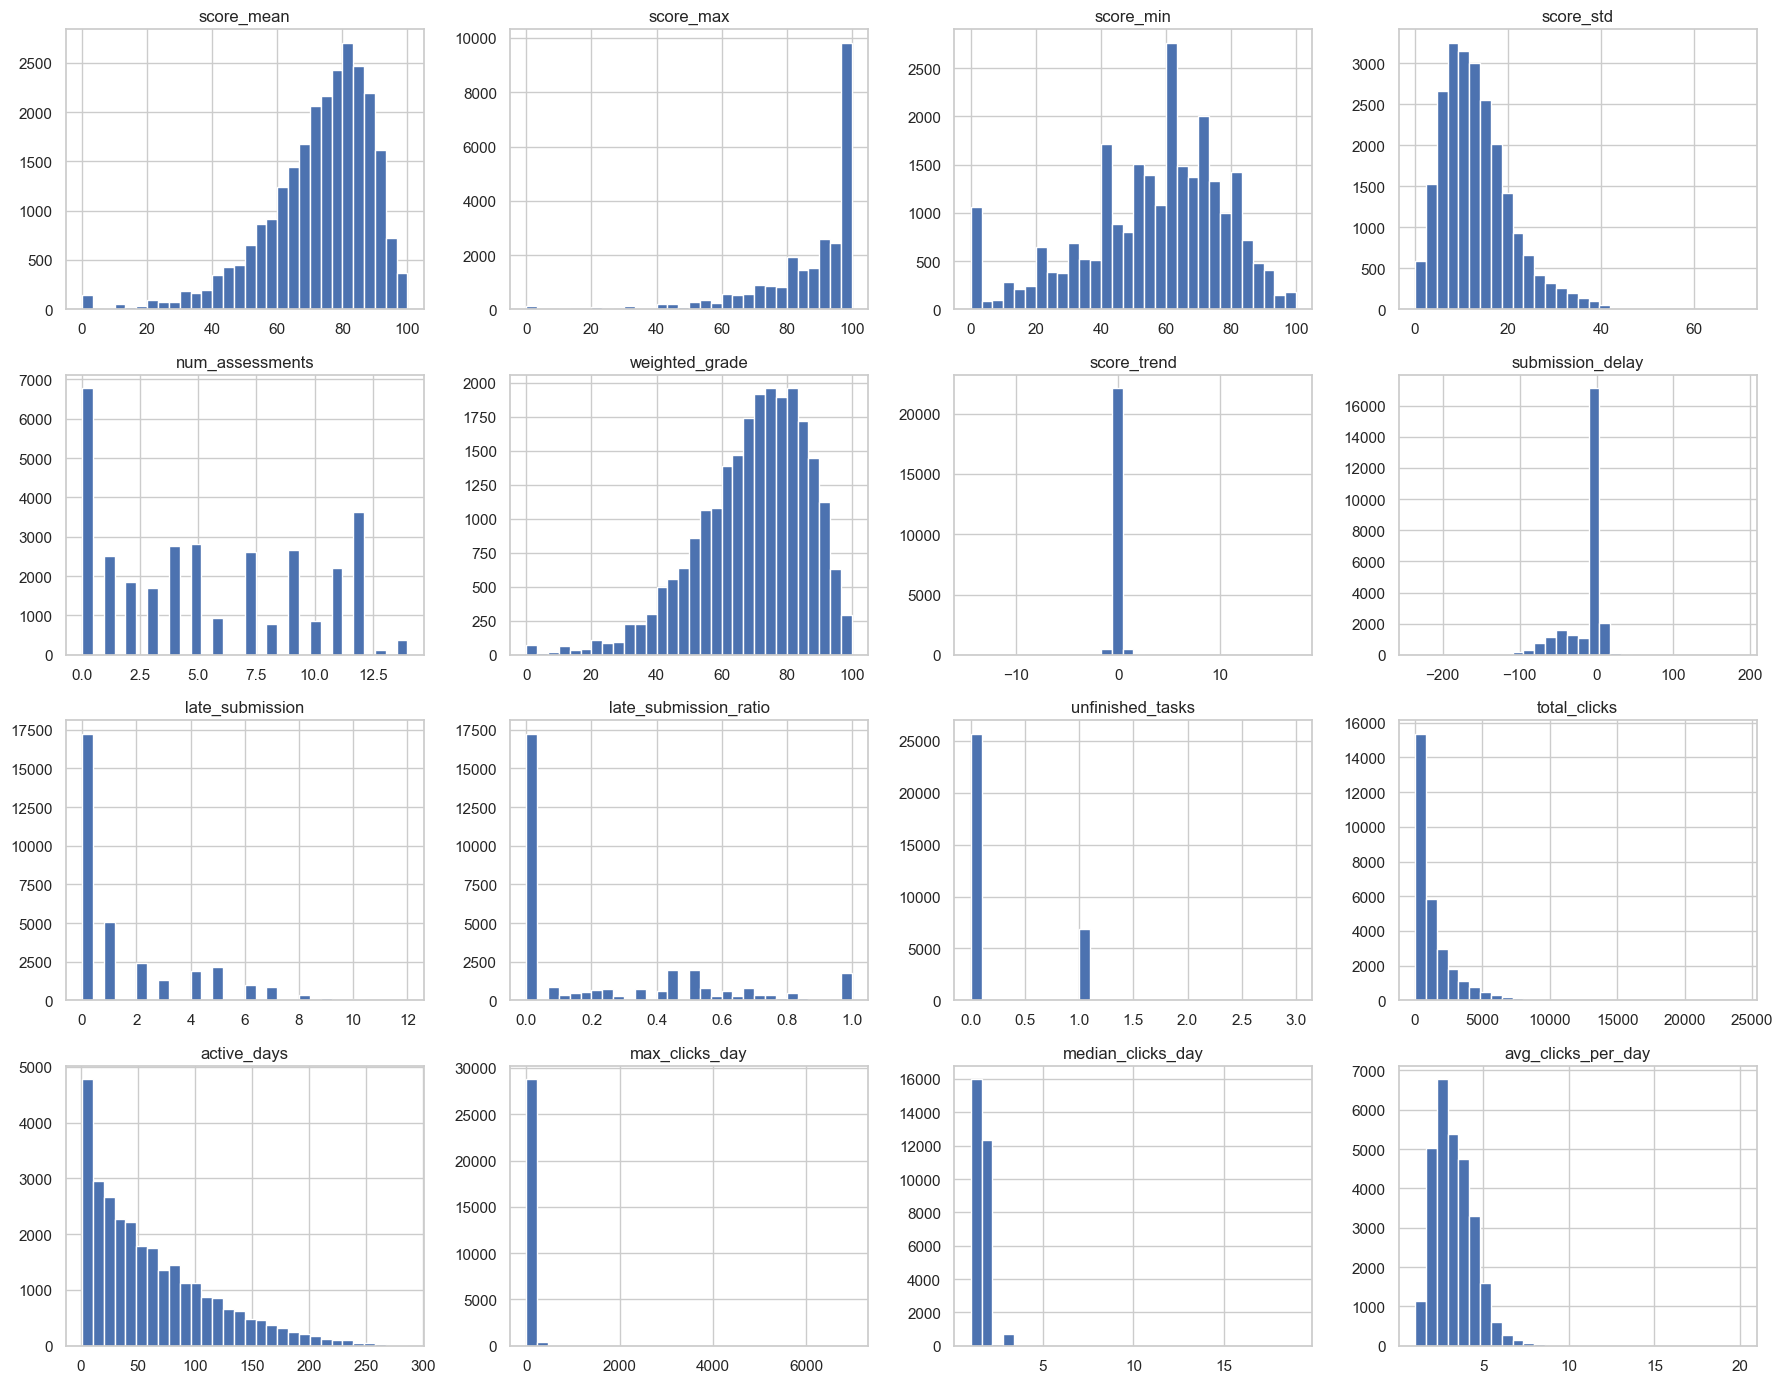

In [41]:
# ==========================================
# Histogramas
# ==========================================

dataset_enriched[new_features].hist(

    figsize=(18,14),

    bins=30

)

plt.tight_layout()

plt.show()

# 16. Matriz de correlación

In [42]:
# ==========================================
# Matriz de correlación
# ==========================================

corr = dataset_enriched[new_features].corr(
    numeric_only=True
)

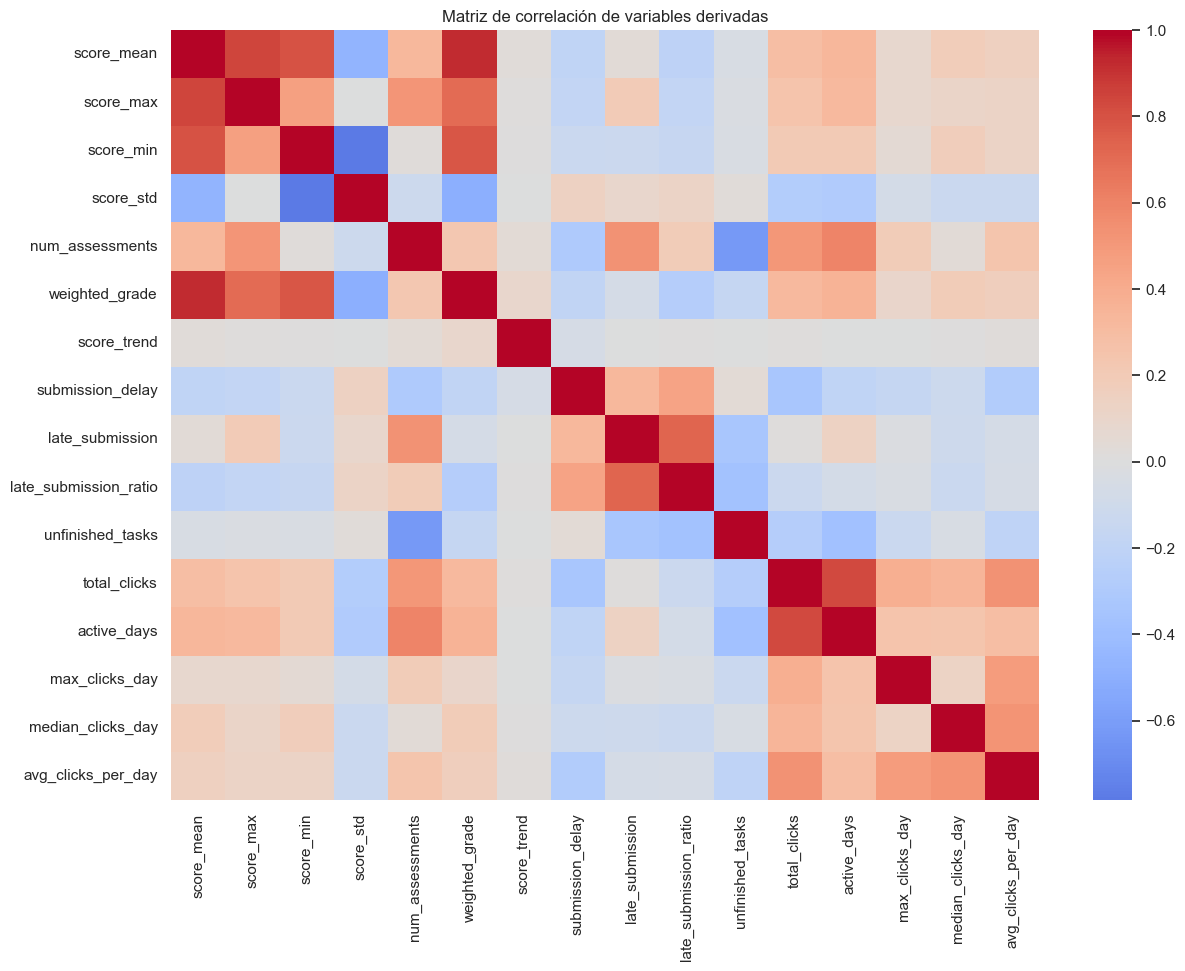

In [43]:
plt.figure(figsize=(14,10))

sns.heatmap(

    corr,

    cmap="coolwarm",

    center=0

)

plt.title("Matriz de correlación de variables derivadas")

plt.show()

# 17. Exportación del dataset enriquecido

In [44]:
dataset_enriched.drop(

    columns=[

        "id_assessment",
        "date_submitted",
        "assessment_type",
        "date",
        "weight",
        "score"

    ],

    inplace=True

)

In [45]:
# ==========================================
# Exportación del dataset
# ==========================================

dataset_enriched.to_csv(

    INTERIM_PATH + "dataset_enriched.csv",

    index=False

)

print("Dataset exportado correctamente.")

Dataset exportado correctamente.


## Interpretación de resultados

El conjunto de datos enriquecido integra todas las variables derivadas construidas durante esta actividad. Cada registro conserva la información original del estudiante y se complementa con indicadores académicos, temporales y de interacción que servirán como variables predictoras en las etapas posteriores del proyecto.

# 8. Conclusiones de la Actividad 2

Durante esta actividad se desarrolló el proceso de transformación e ingeniería de características sobre el conjunto de datos depurado obtenido en la Actividad 1. Como resultado, se construyeron variables derivadas que resumen el rendimiento académico, la evolución temporal de las calificaciones, el comportamiento en la entrega de evaluaciones y el nivel de interacción de los estudiantes con el entorno virtual de aprendizaje.

El conjunto de datos enriquecido integra estas nuevas características junto con la variable objetivo academic_risk, conformando una base de datos preparada para las etapas de preprocesamiento final, selección de variables y entrenamiento de modelos predictivos que serán desarrolladas en la Actividad 3.